Plot delle telemetria

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Caricati 376 giri dal file Parquet.

Analizziamo il pilota: VER
✅ Giro PUSH trovato: 0 days 00:01:29.179000 (Giro 16.0)
✅ Giro SAVE trovato (Long Run): 0 days 00:01:36.527000 (Giro 13.0)

Scaricamento telemetria dalla cache...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
c:\Users\gianl\anaconda3\Lib\site-packages\fastf1\core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
c:\Users\gianl\anaconda3\Lib\site-packages\fastf1\core.py:3035: FutureWarning: pick_lap is deprecated and will be removed in a future release. Use pick_laps instead.
  warnings.warn(("pick_lap is deprecated and will be removed in a "
core           INFO 	Loading data for Bahrain Grand Prix - Practice 2 [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_sta

Dati pronti per il grafico!


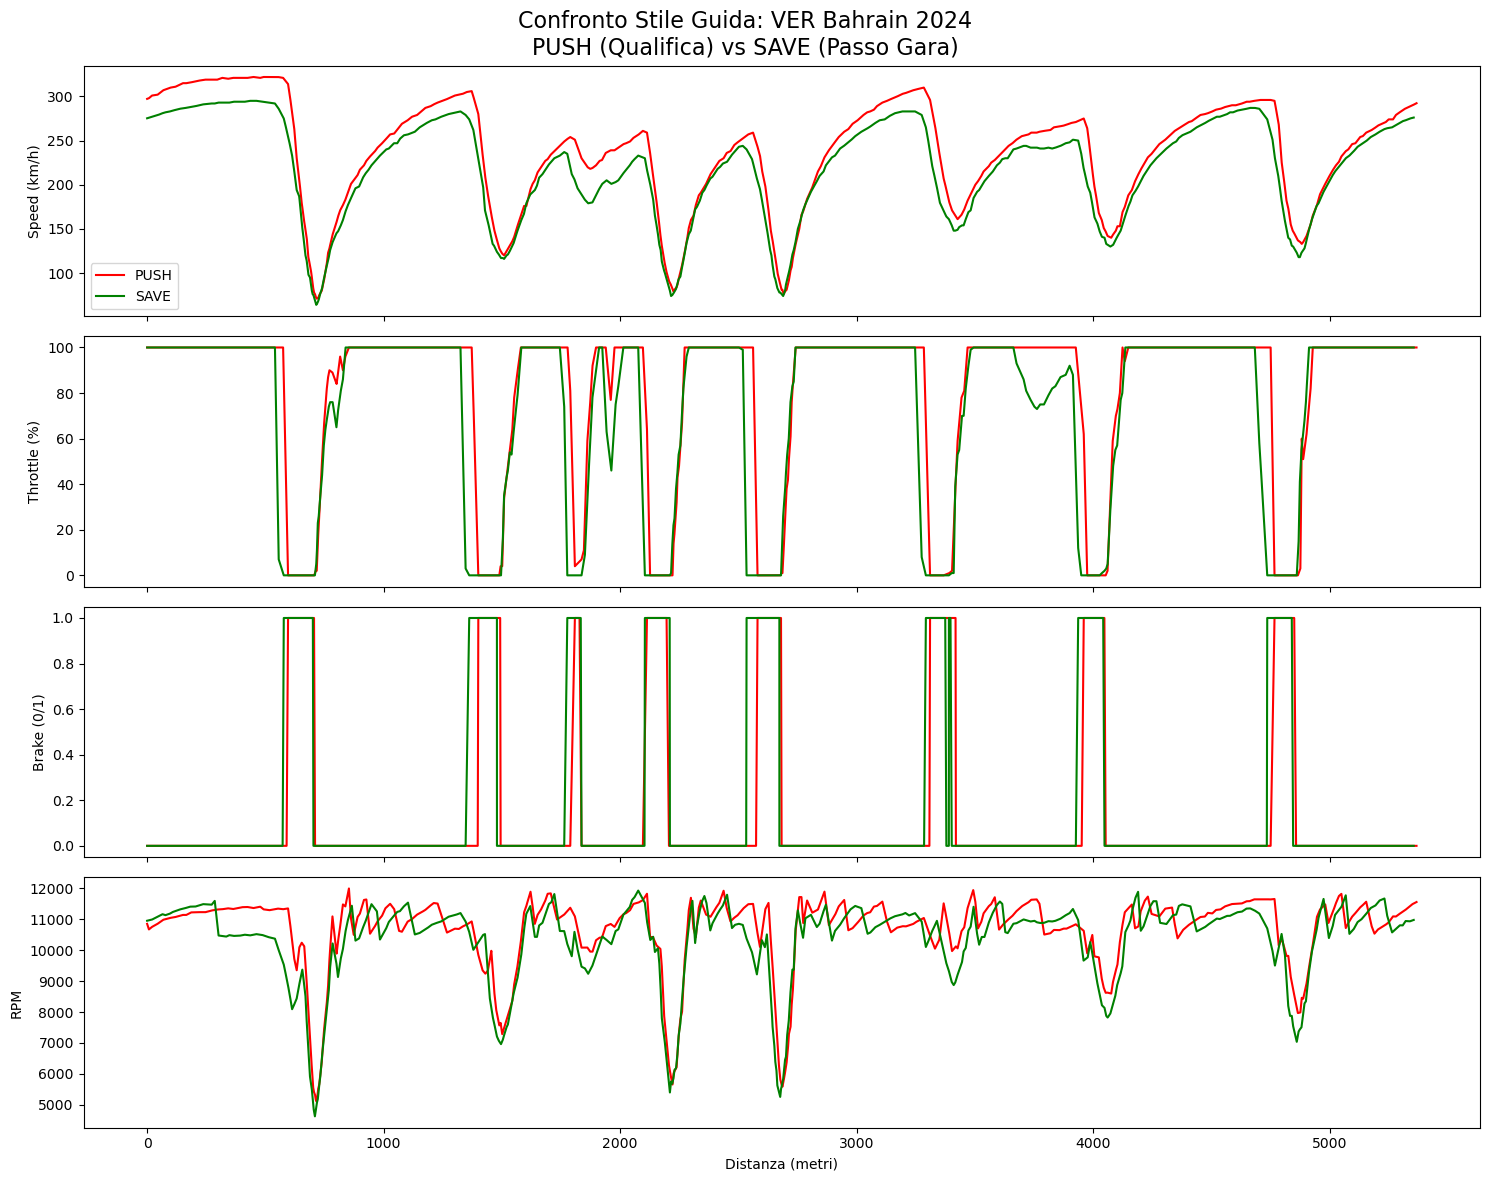

In [105]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- CONFIGURAZIONE ---
CACHE_DIR = r'C:\temp\fastf1_cache'  # <--- Modifica se necessario!
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)
fastf1.Cache.enable_cache(CACHE_DIR)

# 1. CARICHIAMO UN FILE PARQUET (L'Indice)
# Scegliamo una gara a caso scaricata, es. Bahrain 2024
# Assicurati che il file esista in data/raw!
file_path = '../../../data/raw/2024_Bahrain Grand Prix_laps.parquet'

if not os.path.exists(file_path):
    print(f"ERRORE: Non trovo il file in {file_path}. Hai scaricato i dati?")
else:
    df_laps = pd.read_parquet(file_path)
    print(f"Caricati {len(df_laps)} giri dal file Parquet.")

# 2. SELEZIONIAMO UN PILOTA E I GIRI
    driver = 'VER' # Puoi provare anche 'LEC', 'SAI', 'PER'
    print(f"\nAnalizziamo il pilota: {driver}")

    # --- CERCA GIRO PUSH ---
    push_data = df_laps[(df_laps['Driver'] == driver) & (df_laps['Label'] == 1)]
    if not push_data.empty:
        # Prende il giro più veloce in assoluto registrato
        push_lap_info = push_data.sort_values('LapTime').iloc[0]
        print(f"✅ Giro PUSH trovato: {push_lap_info['LapTime']} (Giro {push_lap_info['LapNumber']})")
    else:
        print("❌ Nessun giro PUSH trovato.")
        push_lap_info = None

    # --- CERCA GIRO SAVE ---
    save_data = df_laps[(df_laps['Driver'] == driver) & (df_laps['Label'] == 0)]
    if not save_data.empty:
        # Proviamo a prendere un giro centrale (es. il 5°), se non c'è prendiamo il primo disponibile
        if len(save_data) > 5:
            save_lap_info = save_data.iloc[5]
            print(f"✅ Giro SAVE trovato (Long Run): {save_lap_info['LapTime']} (Giro {save_lap_info['LapNumber']})")
        else:
            save_lap_info = save_data.iloc[0]
            print(f"⚠️ Giro SAVE trovato (Short Run): {save_lap_info['LapTime']} (Giro {save_lap_info['LapNumber']})")
    else:
        print("❌ Nessun giro SAVE trovato nel dataset.")
        save_lap_info = None

    # --- STOP DI SICUREZZA ---
    if push_lap_info is None or save_lap_info is None:
        print("\n⛔ ERRORE CRITICO: Mancano i dati per il confronto.")
        print("Prova a cambiare pilota (es. driver = 'LEC') o controlla se il download dei dati è andato a buon fine.")
        # Interrompe l'esecuzione qui per non dare l'errore rosso dopo
        raise SystemExit("Dati insufficienti per il grafico.")

    # 3. SCARICHIAMO LA TELEMETRIA REALE
    print("\nScaricamento telemetria dalla cache...")
    
    # Carica Sessione PUSH
    session_push = fastf1.get_session(2024, 'Bahrain', 'Q')
    session_push.load(telemetry=True, weather=False, messages=False)
    lap_push = session_push.laps.pick_driver(driver).pick_lap(push_lap_info['LapNumber'])
    tel_push = lap_push.get_telemetry()
    
    # Carica Sessione SAVE
    session_save = fastf1.get_session(2024, 'Bahrain', 'FP2')
    session_save.load(telemetry=True, weather=False, messages=False)
    lap_save = session_save.laps.pick_driver(driver).pick_lap(save_lap_info['LapNumber'])
    tel_save = lap_save.get_telemetry()

    print("Dati pronti per il grafico!")

    # 4. GRAFICO A CONFRONTO
    fig, ax = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
    
    # Titolo
    plt.suptitle(f"Confronto Stile Guida: {driver} Bahrain 2024\nPUSH (Qualifica) vs SAVE (Passo Gara)", fontsize=16)

    # A. Velocità
    ax[0].plot(tel_push['Distance'], tel_push['Speed'], color='red', label='PUSH')
    ax[0].plot(tel_save['Distance'], tel_save['Speed'], color='green', label='SAVE')
    ax[0].set_ylabel("Speed (km/h)")
    ax[0].legend()
    
    # B. Acceleratore (Throttle)
    ax[1].plot(tel_push['Distance'], tel_push['Throttle'], color='red')
    ax[1].plot(tel_save['Distance'], tel_save['Throttle'], color='green')
    ax[1].set_ylabel("Throttle (%)")
    
    # C. Freno (Brake)
    ax[2].plot(tel_push['Distance'], tel_push['Brake'], color='red')
    ax[2].plot(tel_save['Distance'], tel_save['Brake'], color='green')
    ax[2].set_ylabel("Brake (0/1)")

    # D. Giri Motore (RPM)
    ax[3].plot(tel_push['Distance'], tel_push['RPM'], color='red')
    ax[3].plot(tel_save['Distance'], tel_save['RPM'], color='green')
    ax[3].set_ylabel("RPM")
    ax[3].set_xlabel("Distanza (metri)")

    plt.tight_layout()
    plt.show()

In [106]:
# Diagnostica del file Parquet
print("--- CONTENUTO DEL DATASET ---")
print(f"Totale giri: {len(df_laps)}")
print("\nConteggio per tipo (1=PUSH, 0=SAVE):")
print(df_laps['Label'].value_counts())

print("\nPiloti che hanno giri SAVE (Label 0):")
drivers_with_save = df_laps[df_laps['Label'] == 0]['Driver'].unique()
print(drivers_with_save)

--- CONTENUTO DEL DATASET ---
Totale giri: 376

Conteggio per tipo (1=PUSH, 0=SAVE):
Label
0    291
1     85
Name: count, dtype: int64

Piloti che hanno giri SAVE (Label 0):
['VER' 'SAR' 'RIC' 'NOR' 'GAS' 'PER' 'ALO' 'LEC' 'STR' 'MAG' 'TSU' 'ALB'
 'ZHO' 'HUL' 'OCO' 'HAM' 'SAI' 'RUS' 'BOT' 'PIA']


Vediamo quanti giri totali abbiamo su cui addestrare la CNN (dopo aver tolto le gare in cui non è presente l'ID del pilota e che sono dunque inutilizzabili, e quelle che presentano troppi pochi dati)

In [104]:
import pandas as pd
import os
import fastf1

# Configura la cache (per non riscaricare nulla)
CACHE_DIR = r'C:\temp\fastf1_cache' # <--- ASSICURATI CHE SIA IL PERCORSO GIUSTO!
if not os.path.exists(CACHE_DIR):
    # Se non hai spostato la cache, usa quella di default nel progetto
    CACHE_DIR = '../../../fastf1_cache' 

fastf1.Cache.enable_cache(CACHE_DIR)

# Percorso dei dati raw
data_dir = "../../../data/raw"

print(f"📊 CONTEGGIO DATASET TRAINING\n")

total_valid_laps = 0
valid_races = 0
corrupted_races = 0

# Lista di tutti i file parquet
files = [f for f in os.listdir(data_dir) if f.endswith('.parquet')]

for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    
    try:
        # 1. Leggiamo l'indice (leggero)
        df = pd.read_parquet(file_path)
        
        # Se il file è vuoto, lo saltiamo
        if len(df) == 0:
            corrupted_races += 1
            continue

        # 2. PROVA DEL FUOCO: Verifichiamo se riusciamo a caricare la sessione
        # Prendiamo l'anno e la gara dal nome del file (es. "2024_Bahrain_laps.parquet")
        parts = file_name.split('_')
        year = int(parts[0])
        race_name = parts[1] # "Bahrain"
        
        # Proviamo a caricare la sessione FP2 (che è quella spesso più problematica)
        # Se carica questa, al 90% è tutto ok.
        try:
            # Carichiamo in modalità "leggera" (senza telemetria completa per ora) solo per vedere se esiste
            session = fastf1.get_session(year, race_name, 'FP2')
            # Non facciamo .load() completo per risparmiare tempo, ci fidiamo del parquet se non è vuoto
            # Ma verifichiamo se ci sono giri etichettati
            
            n_push = len(df[df['Label'] == 1])
            n_save = len(df[df['Label'] == 0])
            
            # Se mancano totalmente i giri SAVE o PUSH, la gara vale metà
            if n_push == 0 or n_save == 0:
                print(f"⚠️ {year} {race_name}: Parziale (Push: {n_push}, Save: {n_save})")
            else:
                # Gara perfetta
                pass

            total_valid_laps += len(df)
            valid_races += 1
            
        except Exception:
            corrupted_races += 1
            print(f"❌ {year} {race_name}: Errore caricamento sessione FastF1")

    except Exception as e:
        print(f"❌ {file_name}: File Parquet illeggibile")
        corrupted_races += 1

print("\n" + "="*30)
print(f"🏁 RISULTATO FINALE")
print(f"Gare Valide (o parziali): {valid_races}")
print(f"Gare Corrotte/Vuote: {corrupted_races}")
print(f"---------------------------")
print(f"TOTALE GIRI DI TRAINING: {total_valid_laps}")
print(f"---------------------------")

if total_valid_laps > 5000:
    print("✅ DATASET ECCELLENTE! Hai abbastanza dati per il Deep Learning.")
elif total_valid_laps > 2000:
    print("⚠️ DATASET SUFFICIENTE. La rete imparerà, ma potrebbe generalizzare meno.")
else:
    print("⛔ DATASET INSUFFICIENTE. Serve scaricare più anni.")

📊 CONTEGGIO DATASET TRAINING


🏁 RISULTATO FINALE
Gare Valide (o parziali): 32
Gare Corrotte/Vuote: 0
---------------------------
TOTALE GIRI DI TRAINING: 11390
---------------------------
✅ DATASET ECCELLENTE! Hai abbastanza dati per il Deep Learning.
